[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mento-calc/mento/blob/main/docs/source/examples/rectangular_beam_design_ACI_318-19_imperial.ipynb)

In [1]:
# Google Colab does not ship mento, so install it when running there.
# Guarded so that building the documentation never shells out to pip.
import sys

if "google.colab" in sys.modules:
    %pip install mento

# Rectangular Beam design ACI 318-19 (US customary units)

The same example in US customary units. A concrete given in `psi` makes the section US customary, and everything mento prints follows: in, in², in²/ft, psi, ksi, kip and kip·ft, with bars named by their ASTM size (`#5`) and spacings after an `@`. See [Units](../user_guide/units.rst#us-customary-output).

**Define concrete and steel materials, and then assign the beam**

In [2]:
from mento import Concrete_ACI_318_19, SteelBar, RectangularBeam, psi, ksi, inch, ft, kip
from mento import Forces, Node

# Define materials
concrete = Concrete_ACI_318_19(name="4000 psi", f_c=4000 * psi)
steel = SteelBar(name="Grade 60", f_y=60 * ksi)

# Define beam geometry
beam = RectangularBeam(
    label="B101", concrete=concrete, steel_bar=steel, width=10 * inch, height=20 * inch, c_c=1.5 * inch
)
beam.data

Beam B101, $b$=10.00 in, $h$=20.00 in, $c_{c}$=1.50 in,                         Concrete 4000 psi, Rebar Grade 60.

**Define list of forces applied to the beam**

In [3]:
# Define forces
f1 = Forces(label="1.4D", V_z=12 * kip, M_y=60 * kip * ft)
f2 = Forces(label="1.2D+1.6L", V_z=13 * kip, M_y=-22 * kip * ft)
print(f1)
print(f2)

Force ID: 1, Label: 1.4D, N_x: 0.00 kip, V_z: 12.00 kip, M_y: 60.00 ft·kip
Force ID: 2, Label: 1.2D+1.6L, N_x: 0.00 kip, V_z: 13.00 kip, M_y: -22.00 ft·kip


**Create node and assign beam section and list of forces**

In [4]:
node_1 = Node(section=beam, forces=[f1, f2])
node_1

Node ID: 1 - Section label: B101
Forces Applied:
  - Force ID: 1, Label: 1.4D, N_x: 0.00 kip, V_z: 12.00 kip, M_y: 60.00 ft·kip
  - Force ID: 2, Label: 1.2D+1.6L, N_x: 0.00 kip, V_z: 13.00 kip, M_y: -22.00 ft·kip

**Perform shear and bending design**

In [5]:
# Perform design
node_1.design()
# Print results in Markdown format
node_1.results

Beam B101, $b$=10.00 in, $h$=20.00 in, $c_{c}$=1.50 in,                         Concrete 4000 psi, Rebar Grade 60.

Top longitudinal rebar: 2#4, $A_{s,top}$ = 0.39 in², $M_u$ = -22.0 kip·ft, $\phi M_n$ = 30.98 kip·ft → $\color{#439b00}{\text{DCR}=0.71}$ 

Bottom longitudinal rebar: 2#5+1#4, $A_{s,bot}$ = 0.81 in², $M_u$ = 60.0 kip·ft, $\phi M_n$ = 62.37 kip·ft → $\color{#efc200}{\text{DCR}=0.96}$ 

Shear reinforcing 1 stirrup #3 @ 8 in · 6.625 in between legs (max 17.83 in), $A_v$=0.331 in²/ft, $V_u$=13.0 kip, $\phi V_n$=39.06 kip → $\color{#439b00}{\text{DCR}=0.33}$ 

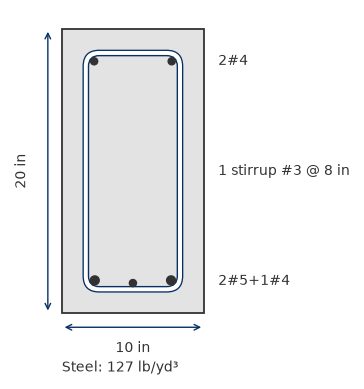

In [6]:
# Plot the beam geometry and reinforcement
beam.plot()

In [7]:
# Print shear results in more detailed format in a DataFrame
node_1.check_shear()

,Label,Comb.,"Av,min","Av,req",Av,Vu,Nu,ØVc,ØVs,ØVn,ØVmax,Vu≤ØVmax,Vu≤ØVn,DCR
0,,,in²/ft,in²/ft,in²/ft,kip,kip,kip,kip,kip,kip,,,
1,B101,1.4D,0.1,0.1,0.331,12.0,0.0,16.91,22.15,39.06,84.56,True,True,0.307
2,B101,1.2D+1.6L,0.1,0.1,0.331,13.0,0.0,16.91,22.15,39.06,84.56,True,True,0.333


In [8]:
# Print flexure results in more detailed format in a DataFrame
node_1.check_flexure()

,Label,Comb.,Position,"As,min","As,req top","As,req bot",As,Mu,ØMn,Mu≤ØMn,DCR
0,,,,in²,in²,in²,in²,kip·ft,kip·ft,,
1,B101,1.4D,Bottom,0.59,0.0,0.78,0.81,60.0,62.37,True,0.962
2,B101,1.2D+1.6L,Top,0.6,0.37,0.0,0.39,-22.0,30.98,True,0.71


**Export table results to Excel**

In [9]:
node_1.check_shear().to_excel("ACI 318-19 US shear_results.xlsx")
node_1.check_flexure().to_excel("ACI 318-19 US flexure_results.xlsx")

**View complete and detailed results for the limiting case of the list of forces**

In [10]:
# View detailed shear results
node_1.shear_results_detailed()

===== BEAM SHEAR DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      B101
Concrete strength                       fc         4000  psi
Steel reinforcement yield strength      fy           60  ksi
Concrete density                        wc        155.0  lb/ft³
Normalweight concrete                   λ             1
Safety factor for shear                 Øv         0.75 

Geometry                     Variable     Value  Unit
--------------------------  ----------  -------  ------
Section height                  h            20  in
Section width                   b            10  in
Clear cover                     cc          1.5  in
Longitudinal tension rebar      As         0.39  in² 

Design forces                     Variable     Value  Unit
-------------------------------  ----------  -------  ------
Axial, positive for compression      

In [11]:
# View detailed flexure results
node_1.flexure_results_detailed()

===== BEAM FLEXURE DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      B101
Concrete strength                       fc         4000  psi
Steel reinforcement yield strength      fy           60  ksi 

Geometry                  Variable     Value  Unit
-----------------------  ----------  -------  ------
Section height               h            20  in
Section width                b            10  in
Clear cover                  cc          1.5  in
Mechanical top cover       cm,top       2.12  in
Mechanical bottom cover    cm,bot       2.17  in 

Design forces       Variable     Value  Unit
-----------------  ----------  -------  ------
Top max moment       Mu,top        -22  kip·ft
Bottom max moment    Mu,bot         60  kip·ft 

Check                     Unit     Value  Min.      Max.  Ok?
-----------------------  ------  -------  ------  -

**Export detailed results to a Word document**

In [12]:
node_1.shear_results_detailed_doc()
node_1.flexure_results_detailed_doc()